<a href="https://colab.research.google.com/github/Sonic815/Machine-Learning/blob/main/Lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
from numpy.linalg import matrix_rank
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from scipy.spatial.distance import minkowski
from numpy.linalg import norm

df = pd.read_excel("Lab Session Data.xlsx",sheet_name="marketing_campaign",usecols="A:AC")
X = df.iloc[:,1:28]
Y = df.iloc[:,28]

for cols in df.columns:
  print("DataType of ",cols,"is" ,df[cols].dtype)

DataType of  ID is int64
DataType of  Year_Birth is int64
DataType of  Education is object
DataType of  Marital_Status is object
DataType of  Income is float64
DataType of  Kidhome is int64
DataType of  Teenhome is int64
DataType of  Dt_Customer is object
DataType of  Recency is int64
DataType of  MntWines is int64
DataType of  MntFruits is int64
DataType of  MntMeatProducts is int64
DataType of  MntFishProducts is int64
DataType of  MntSweetProducts is int64
DataType of  MntGoldProds is int64
DataType of  NumDealsPurchases is int64
DataType of  NumWebPurchases is int64
DataType of  NumCatalogPurchases is int64
DataType of  NumStorePurchases is int64
DataType of  NumWebVisitsMonth is int64
DataType of  AcceptedCmp3 is int64
DataType of  AcceptedCmp4 is int64
DataType of  AcceptedCmp5 is int64
DataType of  AcceptedCmp1 is int64
DataType of  AcceptedCmp2 is int64
DataType of  Complain is int64
DataType of  Z_CostContact is int64
DataType of  Z_Revenue is int64
DataType of  Response is in

In [5]:
def label_encode(column):
  unique = list(set(column))
  mapping={}

  for i,value in enumerate(unique):
      mapping[value] = i

  label =[]

  for value in column:
    label.append(mapping[value])

  return mapping,label

def onehot_encode(column):
    unique = list(set(column))
    mapping ={}

    for i,value in enumerate(unique):
        mapping[value]=i


    label =[]

    for value in column:
      row = [0]* len(unique)
      row[mapping[value]] = 1
      label.append(row)

    return mapping,label

label_df = df.copy()
for cols in label_df.columns:
    if label_df[cols].dtype == "object":
      mapping,label = label_encode(label_df[cols])
      label_df[cols] = label
      print(cols,":",mapping)

onehot_df = df.copy()
for cols in onehot_df.columns:
    if onehot_df[cols].dtype == "object":
      mapping,label = onehot_encode(onehot_df[cols])
      encoded_df = pd.DataFrame(label,columns=[f"{cols}_{category}"for category in mapping.keys()])
      onehot_df = onehot_df.drop(cols,axis=1,)

      onehot_df = pd.concat([onehot_df,encoded_df],axis=1)

      print(cols,':',mapping)


print("label Encodded: ",label_df.shape)
print("onehot Encoded: ", onehot_df.shape)
print("no of features in label encodded: ",label_df.shape[1])
print("noof features in onehot encoded: ",onehot_df.shape[1])


Education : {'2n Cycle': 0, 'Master': 1, 'PhD': 2, 'Basic': 3, 'Graduation': 4}
Marital_Status : {'Alone': 0, 'Absurd': 1, 'Married': 2, 'YOLO': 3, 'Single': 4, 'Widow': 5, 'Divorced': 6, 'Together': 7}
Dt_Customer : {datetime.datetime(2014, 6, 4, 0, 0): 0, '19-06-2014': 1, '31-08-2012': 2, '21-06-2013': 3, datetime.datetime(2014, 12, 3, 0, 0): 4, '13-07-2013': 5, '13-12-2013': 6, '15-11-2013': 7, '18-02-2014': 8, datetime.datetime(2013, 8, 12, 0, 0): 9, '18-08-2013': 10, '28-12-2013': 11, '15-02-2014': 12, '27-01-2014': 13, datetime.datetime(2012, 4, 11, 0, 0): 14, datetime.datetime(2013, 4, 5, 0, 0): 15, '13-03-2014': 16, datetime.datetime(2013, 9, 5, 0, 0): 17, datetime.datetime(2014, 1, 2, 0, 0): 18, '20-12-2012': 19, '27-08-2013': 20, datetime.datetime(2013, 12, 9, 0, 0): 21, '23-05-2014': 22, datetime.datetime(2013, 6, 9, 0, 0): 23, '28-04-2014': 24, '16-10-2013': 25, '26-05-2013': 26, '26-02-2013': 27, datetime.datetime(2013, 5, 7, 0, 0): 28, '25-06-2013': 29, datetime.datetime(

Distance using my own p=  1 is  115672690.0

 Dsitance using inbuilt p=  1 is  115672690.0
Distance using my own p=  2 is  2727904.385728723

 Dsitance using inbuilt p=  2 is  2727904.385728723
Distance using my own p=  3 is  918052.7333432531

 Dsitance using inbuilt p=  3 is  918052.7333432531
Distance using my own p=  4 is  695174.5625935805

 Dsitance using inbuilt p=  4 is  695174.5625935805
Distance using my own p=  5 is  669682.9917218682

 Dsitance using inbuilt p=  5 is  669682.9917218682
Distance using my own p=  6 is  667007.4704791474

 Dsitance using inbuilt p=  6 is  667007.4704791474
Distance using my own p=  7 is  666694.1011655722

 Dsitance using inbuilt p=  7 is  666694.1011655722
Distance using my own p=  8 is  666651.2820553095

 Dsitance using inbuilt p=  8 is  666651.2820553095
Distance using my own p=  9 is  666644.5023224619

 Dsitance using inbuilt p=  9 is  666644.502322462
Distance using my own p=  10 is  666643.2943321972

 Dsitance using inbuilt p=  10 is 

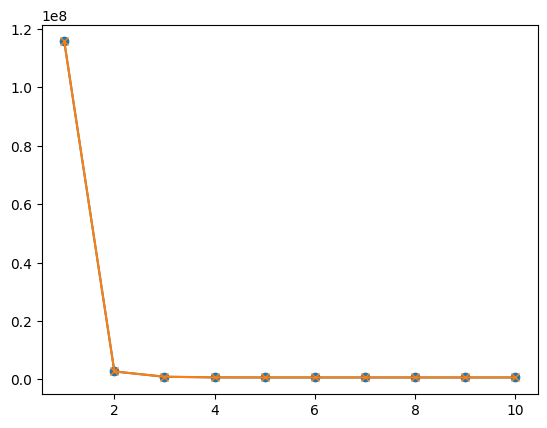

(29725884, 13285.527915743507, 3136.2686428302027)
(29725884, 13285.527915743507, 3136.268642830202)
Mean of  ID is:  5592.159821428571
Variance of  ID is:  10536109.7039214
Standard Deviation of  ID is:  3245.9374152810465
Mean of  Year_Birth is:  1968.8058035714287
Variance of  Year_Birth is:  143.5538056042729
Standard Deviation of  Year_Birth is:  11.98139414276456
Mean of  Income is:  nan
Variance of  Income is:  nan
Standard Deviation of  Income is:  nan
Mean of  Kidhome is:  0.44419642857142855
Variance of  Kidhome is:  0.28974310427295247
Standard Deviation of  Kidhome is:  0.5382779061720372
Mean of  Teenhome is:  0.50625
Variance of  Teenhome is:  0.296389508928571
Standard Deviation of  Teenhome is:  0.5444166684889167
Mean of  Recency is:  49.109375
Variance of  Recency is:  838.4491978236606
Standard Deviation of  Recency is:  28.955987253479385
Mean of  MntWines is:  303.9357142857143
Variance of  MntWines is:  113247.22533163248
Standard Deviation of  MntWines is:  336.5

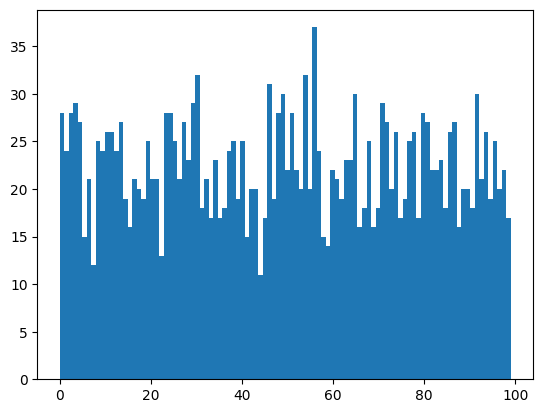

In [6]:
def distance(point1,point2,number):
  if len(point1) != len(point2):
    return "error"

  distance =0

  for x,y in zip(point1,point2):
    temp = abs(x-y)**number
    distance += temp
  distance = distance**(1/number)

  return distance

distance_ownlist = []
distance_inbuilt =[]
point1 = df["Income"].fillna(0)
point2 = df["Recency"].fillna(0)

for i in range(1,11):
  dist_own = distance(point1,point2,i)
  dist_inbuilt = minkowski(point1,point2,i)
  print("Distance using my own p= ",i,"is ",dist_own)
  print("\n Dsitance using inbuilt p= ",i,"is ",dist_inbuilt)
  distance_ownlist.append(dist_own)
  distance_inbuilt.append(dist_inbuilt)

plt.plot(range(1,11),distance_ownlist,marker='o',label="myfucntion")
plt.plot(range(1,11),distance_inbuilt,marker='x',label="inbultfunction")
plt.show()


def dot_length(vector1,vector2):
  dot =0
  for value1,value2 in zip(vector1,vector2):
    dot += value1*value2
  dist1 = 0
  dist2 =0

  for value in vector1:
    dist1 += value**2

  dist1 = dist1**(1/2)

  for value in vector2:
    dist2+=value**2

  dist2 = dist2**(1/2)
  return dot,dist1,dist2

A = df["MntMeatProducts"]
B = df["MntFishProducts"]

def inbuilt(vector1,vector2):
  dot_inbuilt = np.dot(vector1,vector2)
  norm_inbuilt1 = norm(vector1)
  norm_inbuilt2 = norm(vector2)
  return int(dot_inbuilt),float(norm_inbuilt1),float(norm_inbuilt2)
A7 = dot_length(A,B)
A7_inbuilt = inbuilt(A,B)
print(A7)
print(A7_inbuilt)


def mean_own(column):
  mean_own =0
  for value in column:
    mean_own += value

  mean_own = (mean_own)/len(column)
  return mean_own

def stnd_dvt(column):
  stnd_dvt = 0
  mean_vl = mean_own(column)
  for value in column:
    stnd_dvt += (value-mean_vl)**2
  stnd_dvt = stnd_dvt/len(column)
  stnd_dvt = (stnd_dvt)**(1/2)
  return stnd_dvt

def variance_own(column):
  var = stnd_dvt(column)**2
  return var

inbuilt_mean =[]
own_mean =[]
inbuilt_var =[]
own_var =[]
inbuilt_std =[]
own_std=[]
for cols in df.columns:
  if df[cols].dtype in ["int64","float64"]:
    print("Mean of ",cols,"is: ",mean_own(df[cols]))
    print("Variance of ",cols,"is: ",variance_own(df[cols]))
    print("Standard Deviation of ",cols,"is: ",stnd_dvt(df[cols]))
    own_mean.append(mean_own(df[cols]))
    own_var.append(variance_own(df[cols]))
    own_std.append(stnd_dvt(df[cols]))

for cols in df.columns:
  if df[cols].dtype in ["int64","float64"]:
    print("Inbuit Mean of ",cols,"is: ",np.mean(df[cols]))
    print("Inbuit Variance of ",cols,"is: ",np.std(df[cols])**2)
    print("Inbuit Standard Deviation of ",cols,"is: ",np.std(df[cols]))
    inbuilt_mean.append(np.mean(df[cols]))
    inbuilt_std.append(np.std(df[cols]))
    inbuilt_var.append(np.std(df[cols])**2)

print("Own Mean ")
print(own_mean)

print("Inbuilt Mean ")
print(inbuilt_mean)

print("Own Std ")
print(own_std)

print("Inbuilt Std ")
print(inbuilt_std)

print("Inbuilt Variance ")
print(inbuilt_var)

print("Own Variance ")
print(own_var)

A10 = df["Recency"]

count,bins= np.histogram(A10,bins=100)
print("Count: ",count)
print("bins: ",bins)
plt.hist(A10,bins=100)
print("Mean: ",np.mean(A10))
print("Variance: ",np.std(A10)**2)

In [8]:
def kmeans(data, k):
    centroids = []
    for i in range(k):
        centroids.append(list(data.iloc[i]))
    while True:
        cluster = []
        for i in range(k):
            cluster.append([])
        for i in range(len(data)):
            point = list(data.iloc[i])
            min_dist = distance(point, centroids[0], 2)
            index = 0
            for j in range(1, k):
                dist = distance(point, centroids[j], 2)
                if dist < min_dist:
                    min_dist = dist
                    index = j
            cluster[index].append(point)
        new_centroids = []
        for i in range(k):
            centroid = []
            for j in range(len(data.columns)):
                total = 0
                for point in cluster[i]:
                    total += point[j]
                if len(cluster[i]) == 0:
                    centroid.append(0)
                else:
                    centroid.append(total / len(cluster[i]))
            new_centroids.append(centroid)
        if new_centroids == centroids:
            break
        centroids = new_centroids
    return centroids, cluster

data = label_df.select_dtypes(include=["int64","float64"])
data = data.fillna(0)   # <-- the fix: handles the 24 NaN rows in Income

centroids, clusters = kmeans(data, 3)
print("Centroids")
print(centroids)
for i in range(len(clusters)):
    print("Cluster", i+1, ":", len(clusters[i]))

Centroids
[[5471.315914489312, 1965.9049881235155, 2.5866983372921615, 4.258907363420428, 53782.94180522565, 0.37767220902612825, 0.8052256532066508, 330.9477434679335, 49.24346793349169, 313.3206650831354, 20.352731591448933, 109.19477434679335, 27.72209026128266, 19.350356294536816, 47.20902612826603, 3.053444180522565, 4.875296912114014, 2.4180522565320666, 6.371733966745843, 5.562945368171022, 0.06294536817102138, 0.09026128266033254, 0.009501187648456057, 0.022565320665083134, 0.0166270783847981, 0.0059382422802850355, 3.0, 11.0, 0.11045130641330166], [5652.939974457216, 1972.7509578544061, 2.7164750957854404, 4.187739463601533, 27760.431673052364, 0.8033205619412516, 0.33588761174968074, 331.0715197956577, 48.93103448275862, 37.50702426564496, 6.409961685823755, 29.874840357598977, 9.611749680715198, 6.83397190293742, 18.90038314176245, 2.173690932311622, 2.236270753512133, 0.5823754789272031, 3.1468710089399745, 6.841634738186462, 0.0842911877394636, 0.008939974457215836, 0.0012